<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/food101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

--2026-09-30 09:53:07--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.24.207, 172.253.118.207, 64.233.170.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.24.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip.1’

101_food_classes_10 100%[===================>]   1.51G  18.8MB/s    in 85s     

2026-09-30 09:54:32 (18.3 MB/s) - ‘101_food_classes_10_percent.zip.1’ saved [1625420029/1625420029]



In [2]:
import zipfile
zip_ref = zipfile.ZipFile("/content/101_food_classes_10_percent.zip")
zip_ref.extractall()
zip_ref.close()

In [3]:
!ls

101_food_classes_10_percent	 101_food_classes_10_percent.zip.1  __MACOSX
101_food_classes_10_percent.zip  history_3class.log		    sample_data


In [4]:
!ls 101_food_classes_10_percent

test  train


In [5]:
import os

for dirpath, dirnames, filenames in os.walk('101_food_classes_10_percent'):
  print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

there are 2 directories and 0 images in '101_food_classes_10_percent'.
there are 101 directories and 0 images in '101_food_classes_10_percent/test'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/grilled_cheese_sandwich'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/ramen'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/sushi'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/pancakes'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/french_onion_soup'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/caesar_salad'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/samosa'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/grilled_salmon'.
there are 0 directories and 250 images in '101_food_classes_10_percent/test/ceviche'.
there are 0 directories and 250 images in '

In [6]:
import tensorflow as tf
import matplotlib.image as img
%matplotlib inline
import numpy as np
from collections import defaultdict
import collections
from shutil import copy
from shutil import copytree, rmtree
import tensorflow.keras.backend as K
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from tensorflow import keras
from tensorflow.keras import models
import cv2


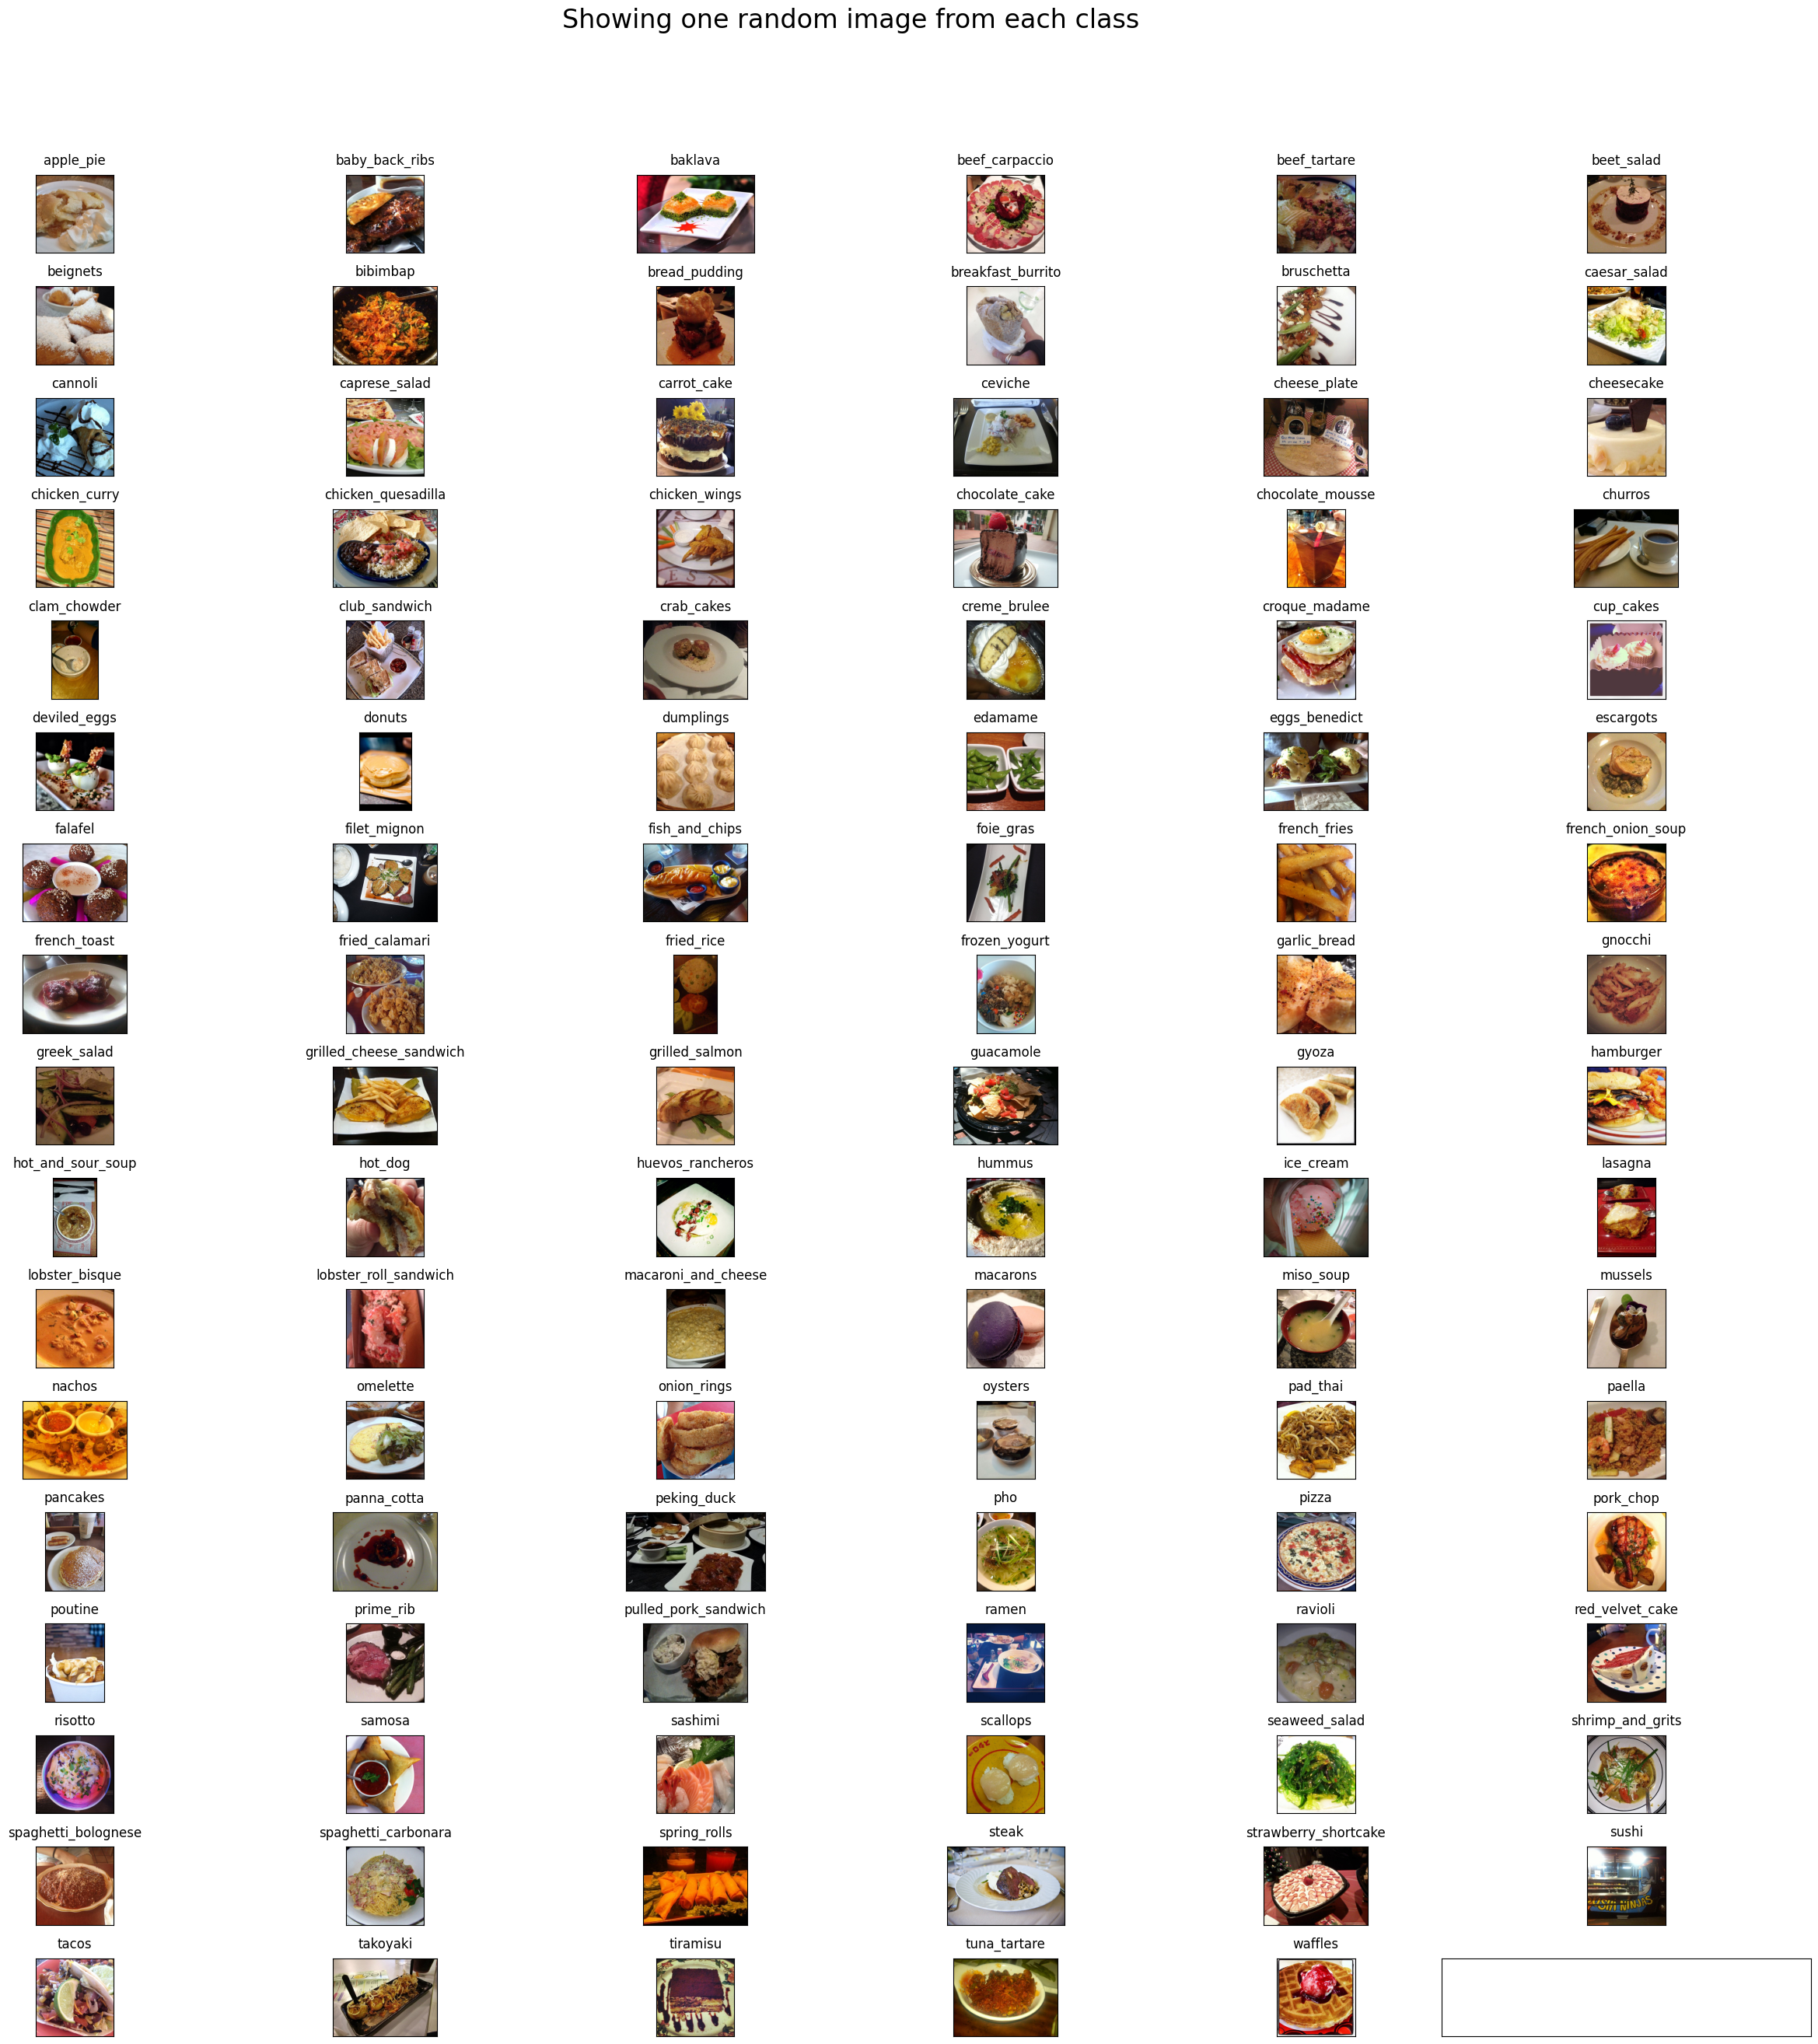

In [7]:
# Visualize the data, showing one image per class from 101 classes
rows = 17
cols = 6
fig, ax = plt.subplots(rows, cols, figsize=(25,25))
fig.suptitle("Showing one random image from each class", y=1.05, fontsize=24) # Adding  y=1.05, fontsize=24 helped me fix the suptitle overlapping with axes issue
data_dir = "/content/101_food_classes_10_percent/train"
foods_sorted = sorted(os.listdir(data_dir))
food_id = 0
for i in range(rows):
  for j in range(cols):
    try:
      food_selected = foods_sorted[food_id]
      food_id += 1
    except:
      break
    if food_selected == '.DS_Store':
        continue
    food_selected_images = os.listdir(os.path.join(data_dir,food_selected)) # returns the list of all files present in each food category
    food_selected_random = np.random.choice(food_selected_images) # picks one food item from the list as choice, takes a list and returns one random item
    img = plt.imread(os.path.join(data_dir,food_selected, food_selected_random))
    ax[i][j].imshow(img)
    ax[i][j].set_title(food_selected, pad = 10)

plt.setp(ax, xticks=[],yticks=[])
plt.tight_layout()

In [8]:
K.clear_session()
n_classes = 101
img_width, img_height = 299, 299
train_data_dir = '/content/101_food_classes_10_percent/test'
validation_data_dir = '/content/101_food_classes_10_percent/train'
nb_train_samples = 25250 #75750
nb_validation_samples = 7575 #25250
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

Found 25250 images belonging to 101 classes.
Found 7575 images belonging to 101 classes.


In [9]:
inception = InceptionV3(weights='imagenet', include_top=False)
x = inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(128,activation='relu')(x)
x = Dropout(0.2)(x)

predictions = Dense(101,kernel_regularizer=regularizers.l2(0.005), activation='softmax')(x)

model = Model(inputs=inception.input, outputs=predictions)
model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
csv_logger = CSVLogger('history_3class.log')

history = model.fit(train_generator,
                    steps_per_epoch = nb_train_samples // batch_size,
                    validation_data=validation_generator,
                    validation_steps=nb_validation_samples // batch_size,
                    epochs=30,
                    verbose=1,
                    callbacks=[csv_logger])

Epoch 1/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 831s 485ms/step - accuracy: 0.0316 - loss: 5.0993 - val_accuracy: 0.0868 - val_loss: 4.9285
Epoch 2/30
   1/1578 ━━━━━━━━━━━━━━━━━━━━ 6:26 245ms/step - accuracy: 0.3125 - loss: 4.8576

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1578/1578 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.3125 - loss: 4.8576 - val_accuracy: 0.0873 - val_loss: 4.9278
Epoch 3/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 742s 470ms/step - accuracy: 0.1281 - loss: 4.7106 - val_accuracy: 0.2365 - val_loss: 4.3141
Epoch 4/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.1250 - loss: 4.7133 - val_accuracy: 0.2359 - val_loss: 4.3139
Epoch 5/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 742s 470ms/step - accuracy: 0.2470 - loss: 4.1062 - val_accuracy: 0.3475 - val_loss: 3.6528
Epoch 6/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.3750 - loss: 4.0051 - val_accuracy: 0.3479 - val_loss: 3.6517
Epoch 7/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 730s 462ms/step - accuracy: 0.3309 - loss: 3.5730 - val_accuracy: 0.4289 - val_loss: 3.1302
Epoch 8/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5625 - loss: 3.0098 - val_accuracy: 0.4294 - val_loss: 3.1302
Epoch 9/30
1578/1578 ━━━━━━━━━━━━━━━━━━━━ 733s 465ms/step - accuracy: 0.4053 - lo

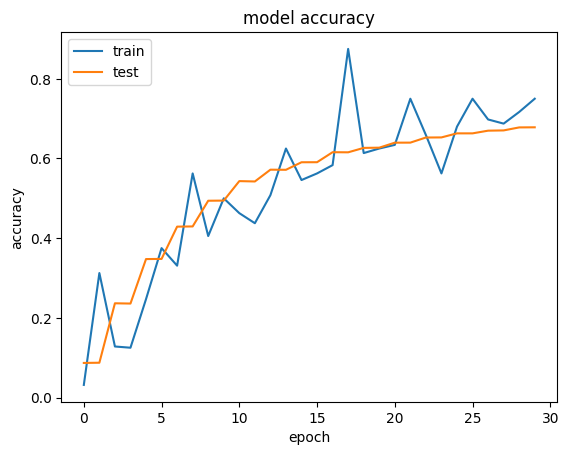

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

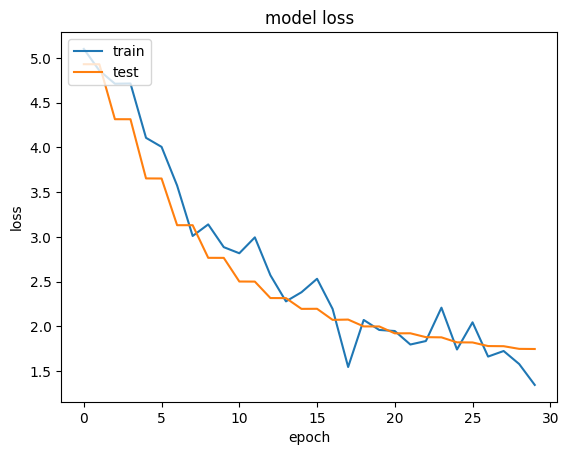

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
#

474/474 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step
Class names:
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll

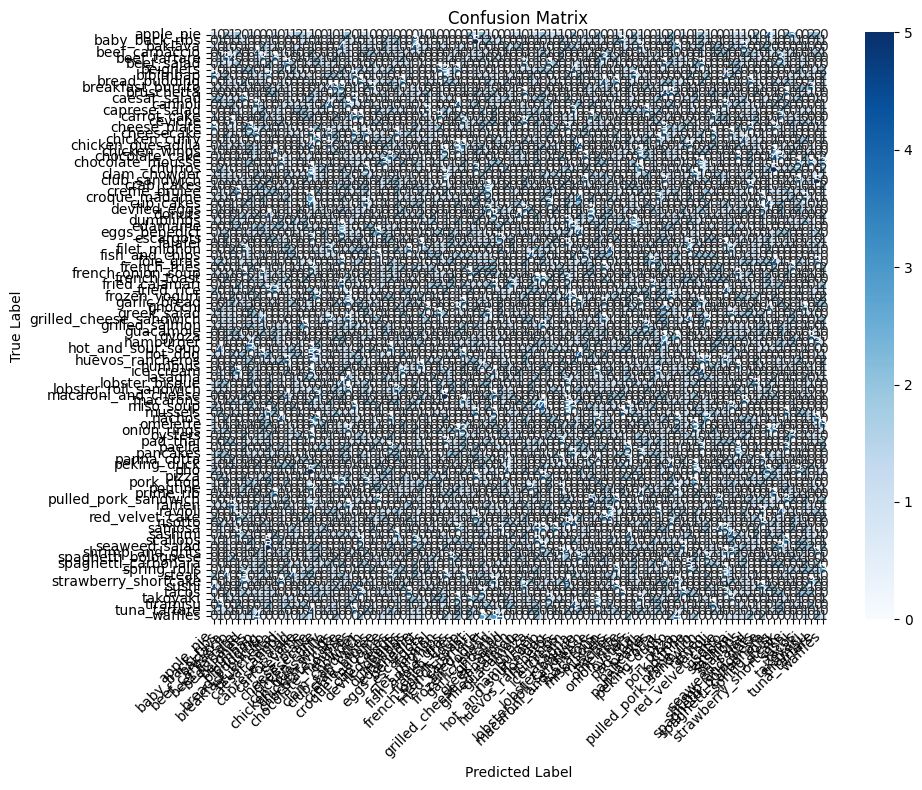

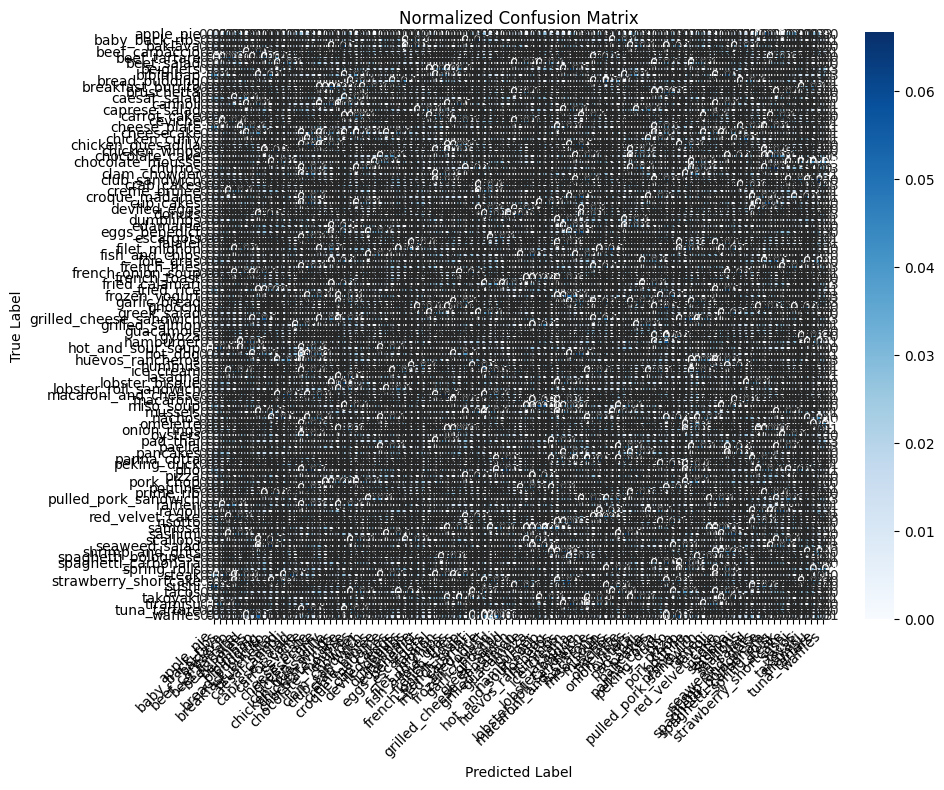


Classification Report:

                         precision    recall  f1-score   support

              apple_pie     0.0189    0.0133    0.0156        75
         baby_back_ribs     0.0154    0.0133    0.0143        75
                baklava     0.0130    0.0133    0.0132        75
         beef_carpaccio     0.0143    0.0133    0.0138        75
           beef_tartare     0.0000    0.0000    0.0000        75
             beet_salad     0.0000    0.0000    0.0000        75
               beignets     0.0222    0.0267    0.0242        75
               bibimbap     0.0122    0.0133    0.0127        75
          bread_pudding     0.0130    0.0133    0.0132        75
      breakfast_burrito     0.0211    0.0267    0.0235        75
             bruschetta     0.0339    0.0267    0.0299        75
           caesar_salad     0.0000    0.0000    0.0000        75
                cannoli     0.0120    0.0133    0.0127        75
          caprese_salad     0.0185    0.0133    0.0155        75

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# IMPORTANT:
# Reset validation generator to the beginning
validation_generator.reset()

# Get predictions
predictions = model.predict(
    validation_generator,
    verbose=1
)

# Convert probabilities to class indices
y_pred = np.argmax(predictions, axis=1)

# Get true labels
y_true = validation_generator.classes

# Class names in the correct order
class_names = list(validation_generator.class_indices.keys())

print("Class names:")
print(class_names)

print("\nNumber of true labels:", len(y_true))
print("Number of predictions:", len(y_pred))

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)

print("\nOverall Accuracy:")
print(f"{accuracy * 100:.2f}%")

# --------------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# CLASSIFICATION REPORT
# --------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

In [13]:
results = model.evaluate(
    train_generator,
    verbose=1
)

print("Loss:", results[0])
print("Accuracy:", results[1])

1579/1579 ━━━━━━━━━━━━━━━━━━━━ 596s 377ms/step - accuracy: 0.8334 - loss: 1.0991
Loss: 1.0990983247756958
Accuracy: 0.8333861231803894
